
Epoch 1
X1 X2 | Target | Pred | Error | Weights | Bias
------------------------------------------------------------
0  0  |   1    |  1   |  0   | [0. 0.] | 0.0
0  1  |   1    |  1   |  0   | [0. 0.] | 0.0
1  0  |   1    |  1   |  0   | [0. 0.] | 0.0
1  1  |   0    |  1   |  -1   | [-0.1 -0.1] | -0.1
Accuracy: 75.00%


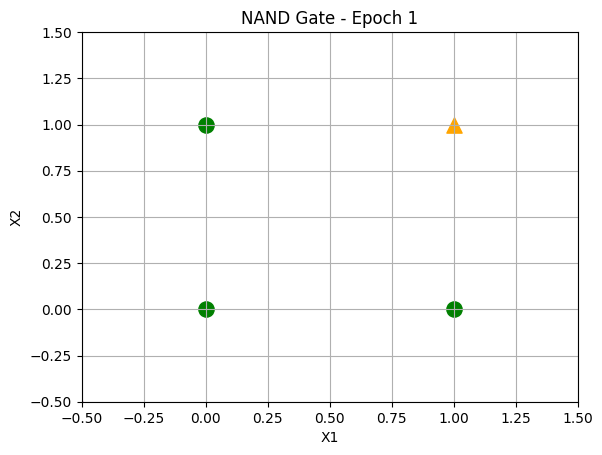


Epoch 2
X1 X2 | Target | Pred | Error | Weights | Bias
------------------------------------------------------------
0  0  |   1    |  0   |  1   | [-0.1 -0.1] | 0.0
0  1  |   1    |  0   |  1   | [-0.1  0. ] | 0.1
1  0  |   1    |  1   |  0   | [-0.1  0. ] | 0.1
1  1  |   0    |  1   |  -1   | [-0.2 -0.1] | 0.0
Accuracy: 25.00%


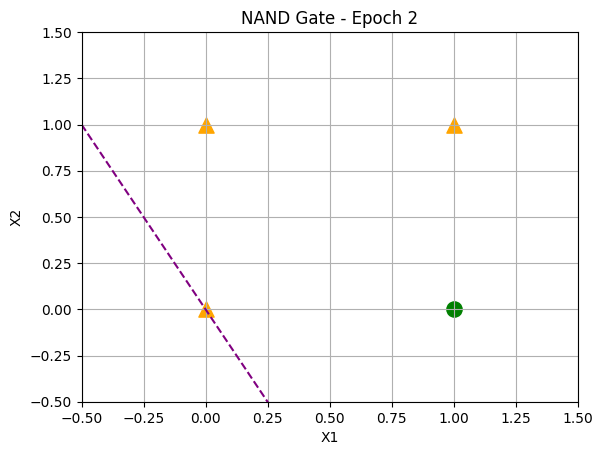


Epoch 3
X1 X2 | Target | Pred | Error | Weights | Bias
------------------------------------------------------------
0  0  |   1    |  1   |  0   | [-0.2 -0.1] | 0.0
0  1  |   1    |  0   |  1   | [-0.2  0. ] | 0.1
1  0  |   1    |  0   |  1   | [-0.1  0. ] | 0.2
1  1  |   0    |  1   |  -1   | [-0.2 -0.1] | 0.1
Accuracy: 25.00%


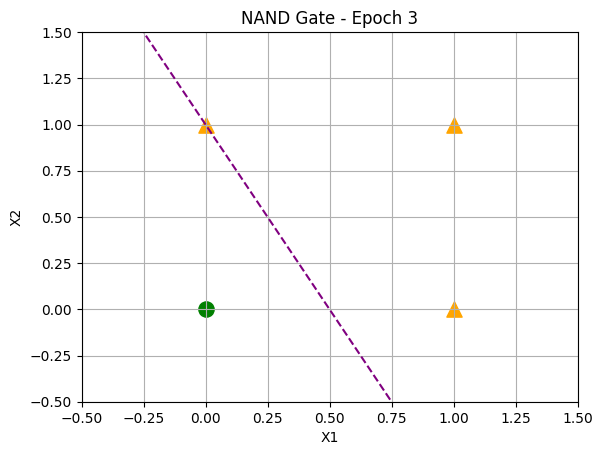


Epoch 4
X1 X2 | Target | Pred | Error | Weights | Bias
------------------------------------------------------------
0  0  |   1    |  1   |  0   | [-0.2 -0.1] | 0.1
0  1  |   1    |  1   |  0   | [-0.2 -0.1] | 0.1
1  0  |   1    |  0   |  1   | [-0.1 -0.1] | 0.2
1  1  |   0    |  1   |  -1   | [-0.2 -0.2] | 0.1
Accuracy: 50.00%


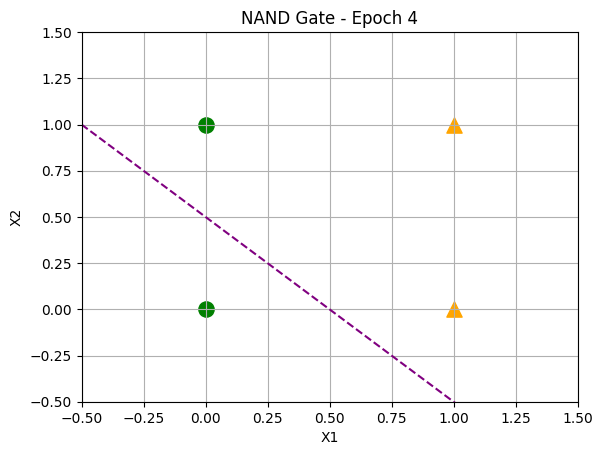


Epoch 5
X1 X2 | Target | Pred | Error | Weights | Bias
------------------------------------------------------------
0  0  |   1    |  1   |  0   | [-0.2 -0.2] | 0.1
0  1  |   1    |  0   |  1   | [-0.2 -0.1] | 0.2
1  0  |   1    |  1   |  0   | [-0.2 -0.1] | 0.2
1  1  |   0    |  0   |  0   | [-0.2 -0.1] | 0.2
Accuracy: 75.00%


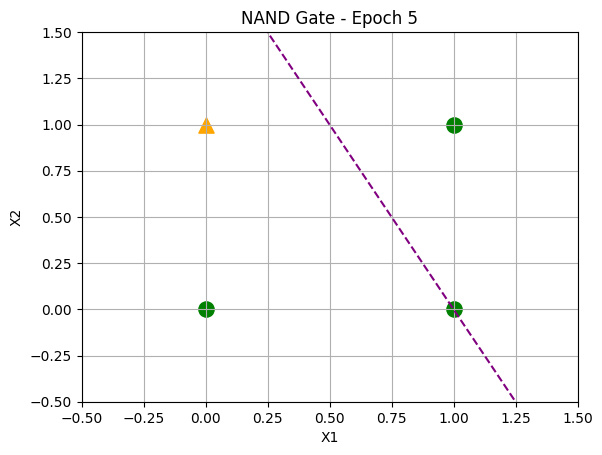


Epoch 6
X1 X2 | Target | Pred | Error | Weights | Bias
------------------------------------------------------------
0  0  |   1    |  1   |  0   | [-0.2 -0.1] | 0.2
0  1  |   1    |  1   |  0   | [-0.2 -0.1] | 0.2
1  0  |   1    |  1   |  0   | [-0.2 -0.1] | 0.2
1  1  |   0    |  0   |  0   | [-0.2 -0.1] | 0.2
Accuracy: 100.00%


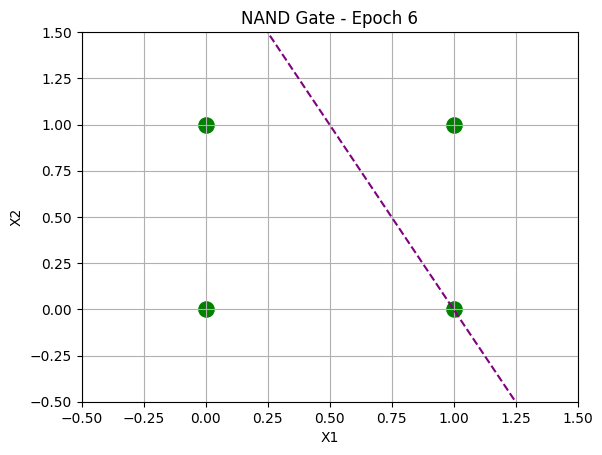


✔ Converged!


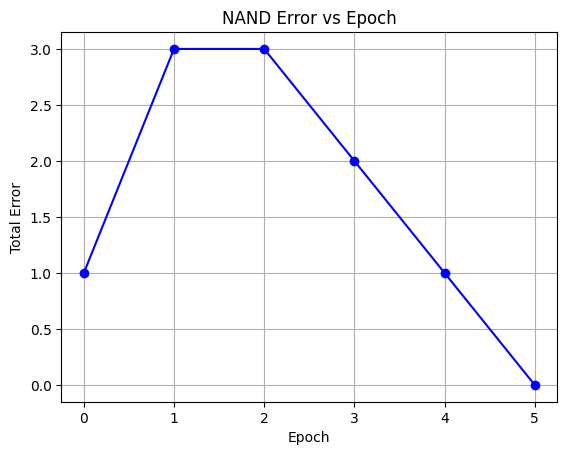

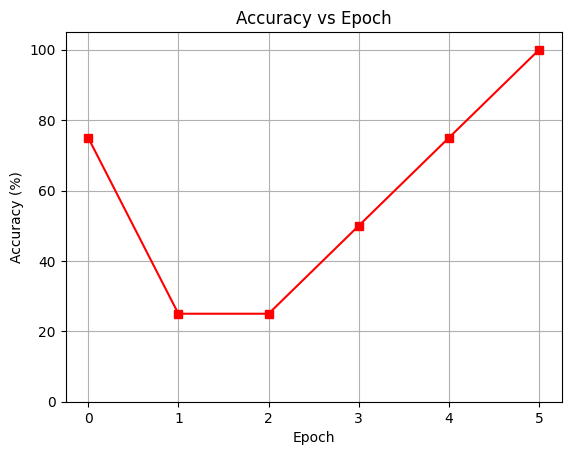

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ---------------- DATA ----------------
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([1, 1, 1, 0])  # NAND output

# ---------------- PARAMETERS ----------------
w = np.array([0.0, 0.0])
b = 0.0
lr = 0.1
epochs = 6

errors_epoch = []
accuracy_epoch = []

plt.ion()

# ---------------- STEP FUNCTION ----------------
def step(x):
    return 1 if x >= 0 else 0

# ---------------- TRAINING ----------------
for epoch in range(epochs):
    total_error = 0
    correct = 0

    print(f"\nEpoch {epoch + 1}")
    print("X1 X2 | Target | Pred | Error | Weights | Bias")
    print("-" * 60)

    preds = []

    for i in range(len(X)):
        z = np.dot(X[i], w) + b
        y_pred = step(z)
        error = y[i] - y_pred

        w = w + lr * error * X[i]
        b = b + lr * error

        total_error += abs(error)
        preds.append(y_pred)

        if y_pred == y[i]:
            correct += 1

        print(f"{X[i][0]}  {X[i][1]}  |   {y[i]}    |  {y_pred}   |  {error}   | {w} | {b}")

    # Accuracy
    accuracy = (correct / len(X)) * 100
    accuracy_epoch.append(accuracy)
    errors_epoch.append(total_error)

    print(f"Accuracy: {accuracy:.2f}%")

    # ---------------- PLOT ----------------
    plt.clf()
    for i in range(len(X)):
        if preds[i] == y[i]:
            plt.scatter(X[i][0], X[i][1], c='green', marker='o', s=120)
        else:
            plt.scatter(X[i][0], X[i][1], c='orange', marker='^', s=120)

    x_vals = np.array([-0.5, 1.5])
    if w[1] != 0:
        y_vals = -(w[0] * x_vals + b) / w[1]
        plt.plot(x_vals, y_vals, color='purple', linestyle='--')

    plt.title(f"NAND Gate - Epoch {epoch + 1}")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.grid()
    plt.xlim(-0.5, 1.5)  # Set x-axis limits to keep origin visible and consistent
    plt.ylim(-0.5, 1.5)  # Set y-axis limits to keep origin visible and consistent
    plt.pause(2)

    if total_error == 0:
        print("\n✔ Converged!")
        break

plt.ioff()

# ---------------- ERROR GRAPH ----------------
plt.figure()
plt.plot(errors_epoch, marker='o', color='blue')
plt.title("NAND Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Total Error")
plt.grid()
plt.show()

# ---------------- ACCURACY GRAPH ----------------
plt.figure()
plt.plot(accuracy_epoch, marker='s', color='red')
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.grid()
plt.show()


Epoch 1
X1 X2 | Target | Predicted | Error | Weights        | Bias
----------------------------------------------------------------------
0  0  |   0    |     1     |   -1   | [0. 0.] | -0.10
0  1  |   1    |     0     |   1   | [0.  0.1] | 0.00
1  0  |   1    |     1     |   0   | [0.  0.1] | 0.00
1  1  |   0    |     1     |   -1   | [-0.1  0. ] | -0.10
Total Error: 3
Accuracy: 25.00%


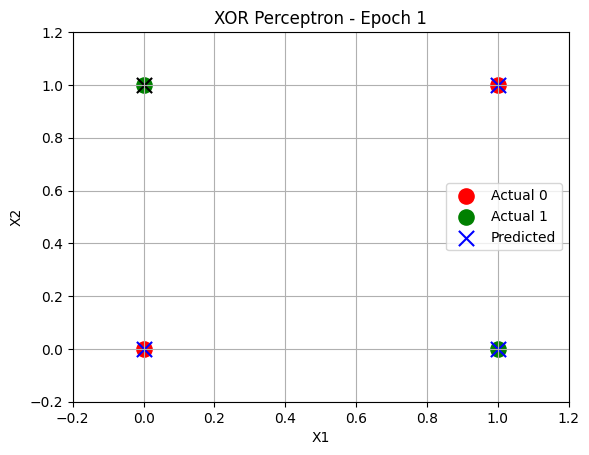


Epoch 2
X1 X2 | Target | Predicted | Error | Weights        | Bias
----------------------------------------------------------------------
0  0  |   0    |     0     |   0   | [-0.1  0. ] | -0.10
0  1  |   1    |     0     |   1   | [-0.1  0.1] | 0.00
1  0  |   1    |     0     |   1   | [0.  0.1] | 0.10
1  1  |   0    |     1     |   -1   | [-0.1  0. ] | 0.00
Total Error: 3
Accuracy: 25.00%


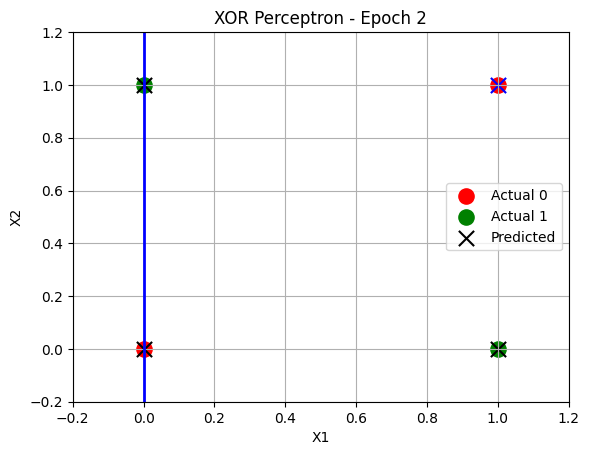


Epoch 3
X1 X2 | Target | Predicted | Error | Weights        | Bias
----------------------------------------------------------------------
0  0  |   0    |     1     |   -1   | [-0.1  0. ] | -0.10
0  1  |   1    |     0     |   1   | [-0.1  0.1] | 0.00
1  0  |   1    |     0     |   1   | [0.  0.1] | 0.10
1  1  |   0    |     1     |   -1   | [-0.1  0. ] | 0.00
Total Error: 4
Accuracy: 0.00%


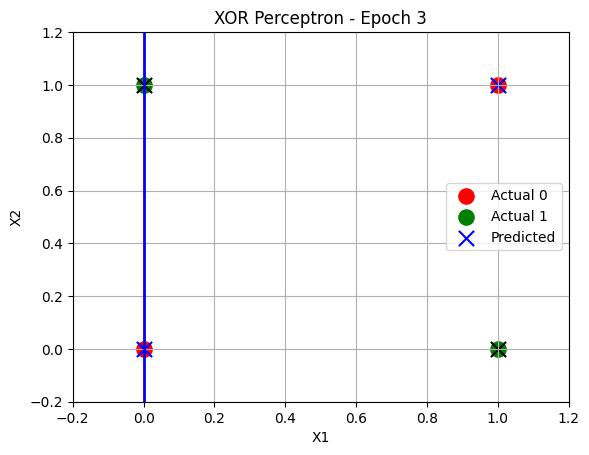


Epoch 4
X1 X2 | Target | Predicted | Error | Weights        | Bias
----------------------------------------------------------------------
0  0  |   0    |     1     |   -1   | [-0.1  0. ] | -0.10
0  1  |   1    |     0     |   1   | [-0.1  0.1] | 0.00
1  0  |   1    |     0     |   1   | [0.  0.1] | 0.10
1  1  |   0    |     1     |   -1   | [-0.1  0. ] | 0.00
Total Error: 4
Accuracy: 0.00%


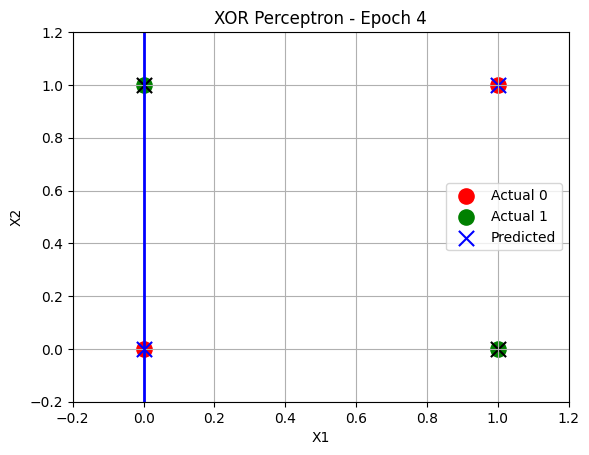


Epoch 5
X1 X2 | Target | Predicted | Error | Weights        | Bias
----------------------------------------------------------------------
0  0  |   0    |     1     |   -1   | [-0.1  0. ] | -0.10
0  1  |   1    |     0     |   1   | [-0.1  0.1] | 0.00
1  0  |   1    |     0     |   1   | [0.  0.1] | 0.10
1  1  |   0    |     1     |   -1   | [-0.1  0. ] | 0.00
Total Error: 4
Accuracy: 0.00%


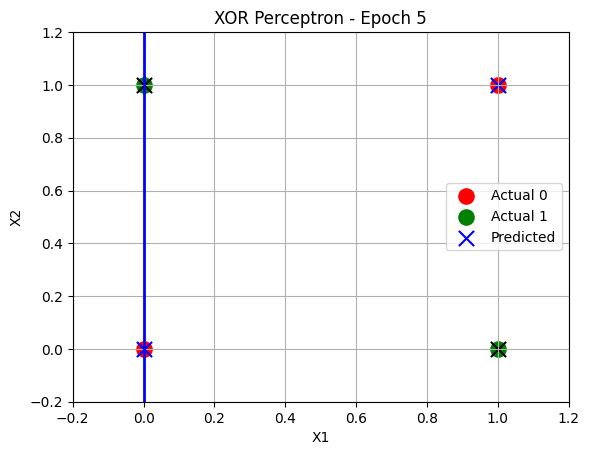


Epoch 6
X1 X2 | Target | Predicted | Error | Weights        | Bias
----------------------------------------------------------------------
0  0  |   0    |     1     |   -1   | [-0.1  0. ] | -0.10
0  1  |   1    |     0     |   1   | [-0.1  0.1] | 0.00
1  0  |   1    |     0     |   1   | [0.  0.1] | 0.10
1  1  |   0    |     1     |   -1   | [-0.1  0. ] | 0.00
Total Error: 4
Accuracy: 0.00%


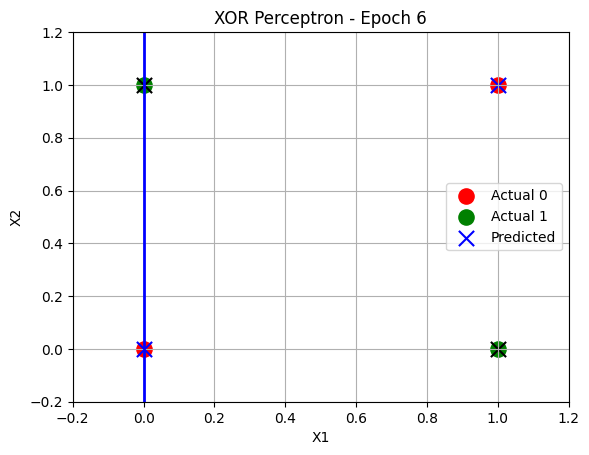


Epoch 7
X1 X2 | Target | Predicted | Error | Weights        | Bias
----------------------------------------------------------------------
0  0  |   0    |     1     |   -1   | [-0.1  0. ] | -0.10
0  1  |   1    |     0     |   1   | [-0.1  0.1] | 0.00
1  0  |   1    |     0     |   1   | [0.  0.1] | 0.10
1  1  |   0    |     1     |   -1   | [-0.1  0. ] | 0.00
Total Error: 4
Accuracy: 0.00%


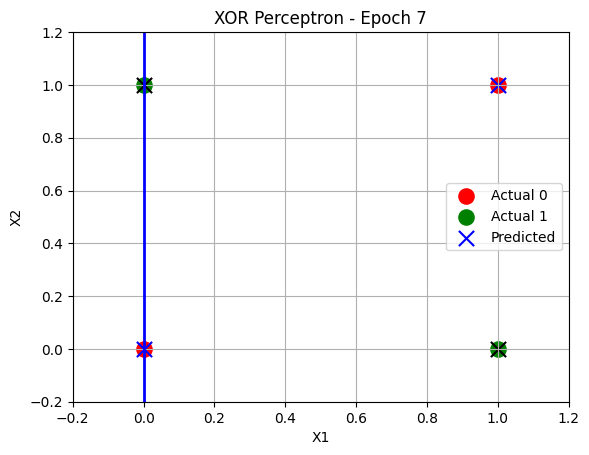


Epoch 8
X1 X2 | Target | Predicted | Error | Weights        | Bias
----------------------------------------------------------------------
0  0  |   0    |     1     |   -1   | [-0.1  0. ] | -0.10
0  1  |   1    |     0     |   1   | [-0.1  0.1] | 0.00
1  0  |   1    |     0     |   1   | [0.  0.1] | 0.10
1  1  |   0    |     1     |   -1   | [-0.1  0. ] | 0.00
Total Error: 4
Accuracy: 0.00%


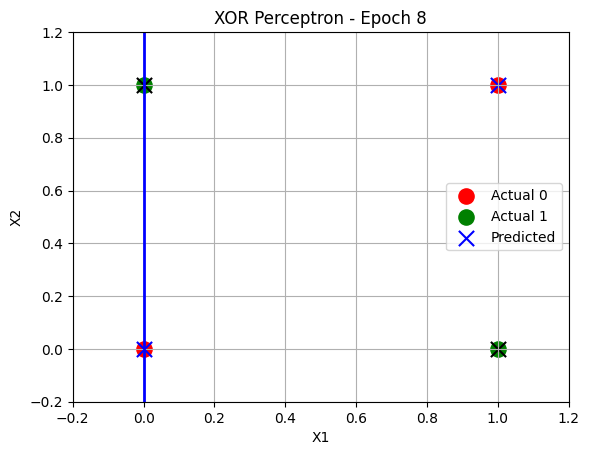


Epoch 9
X1 X2 | Target | Predicted | Error | Weights        | Bias
----------------------------------------------------------------------
0  0  |   0    |     1     |   -1   | [-0.1  0. ] | -0.10
0  1  |   1    |     0     |   1   | [-0.1  0.1] | 0.00
1  0  |   1    |     0     |   1   | [0.  0.1] | 0.10
1  1  |   0    |     1     |   -1   | [-0.1  0. ] | 0.00
Total Error: 4
Accuracy: 0.00%


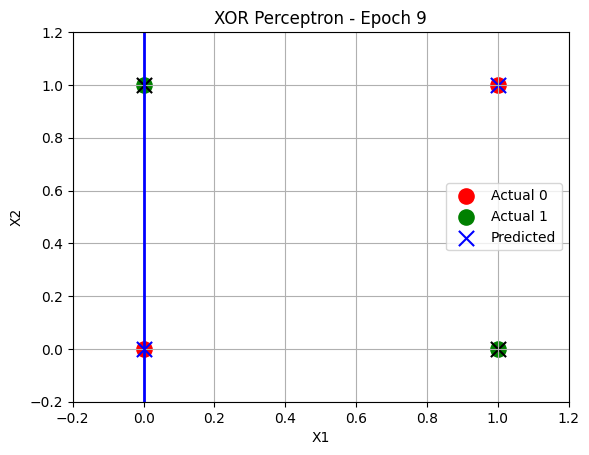


Epoch 10
X1 X2 | Target | Predicted | Error | Weights        | Bias
----------------------------------------------------------------------
0  0  |   0    |     1     |   -1   | [-0.1  0. ] | -0.10
0  1  |   1    |     0     |   1   | [-0.1  0.1] | 0.00
1  0  |   1    |     0     |   1   | [0.  0.1] | 0.10
1  1  |   0    |     1     |   -1   | [-0.1  0. ] | 0.00
Total Error: 4
Accuracy: 0.00%


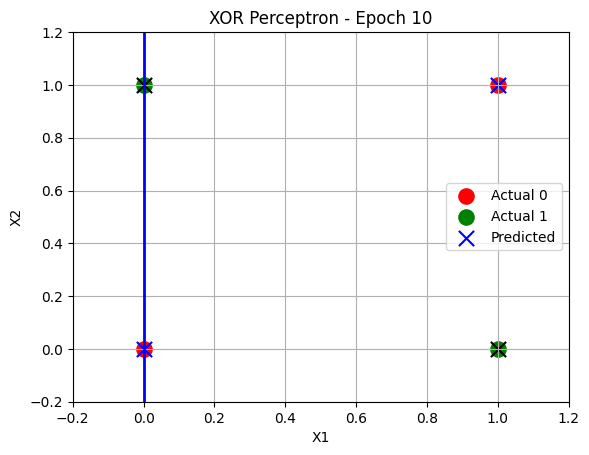


Epoch 11
X1 X2 | Target | Predicted | Error | Weights        | Bias
----------------------------------------------------------------------
0  0  |   0    |     1     |   -1   | [-0.1  0. ] | -0.10
0  1  |   1    |     0     |   1   | [-0.1  0.1] | 0.00
1  0  |   1    |     0     |   1   | [0.  0.1] | 0.10
1  1  |   0    |     1     |   -1   | [-0.1  0. ] | 0.00
Total Error: 4
Accuracy: 0.00%


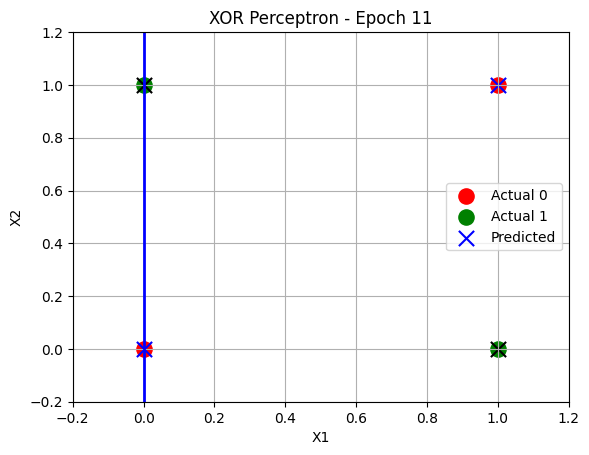


Epoch 12
X1 X2 | Target | Predicted | Error | Weights        | Bias
----------------------------------------------------------------------
0  0  |   0    |     1     |   -1   | [-0.1  0. ] | -0.10
0  1  |   1    |     0     |   1   | [-0.1  0.1] | 0.00
1  0  |   1    |     0     |   1   | [0.  0.1] | 0.10
1  1  |   0    |     1     |   -1   | [-0.1  0. ] | 0.00
Total Error: 4
Accuracy: 0.00%


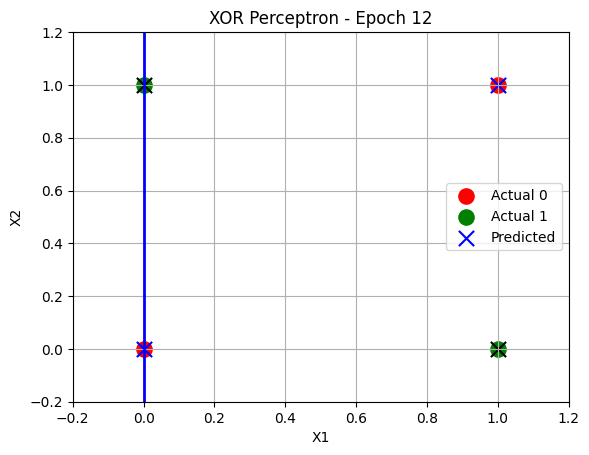


Epoch 13
X1 X2 | Target | Predicted | Error | Weights        | Bias
----------------------------------------------------------------------
0  0  |   0    |     1     |   -1   | [-0.1  0. ] | -0.10
0  1  |   1    |     0     |   1   | [-0.1  0.1] | 0.00
1  0  |   1    |     0     |   1   | [0.  0.1] | 0.10
1  1  |   0    |     1     |   -1   | [-0.1  0. ] | 0.00
Total Error: 4
Accuracy: 0.00%


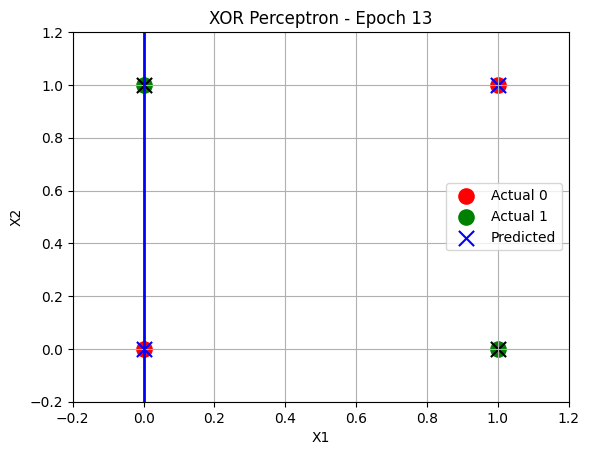


Epoch 14
X1 X2 | Target | Predicted | Error | Weights        | Bias
----------------------------------------------------------------------
0  0  |   0    |     1     |   -1   | [-0.1  0. ] | -0.10
0  1  |   1    |     0     |   1   | [-0.1  0.1] | 0.00
1  0  |   1    |     0     |   1   | [0.  0.1] | 0.10
1  1  |   0    |     1     |   -1   | [-0.1  0. ] | 0.00
Total Error: 4
Accuracy: 0.00%


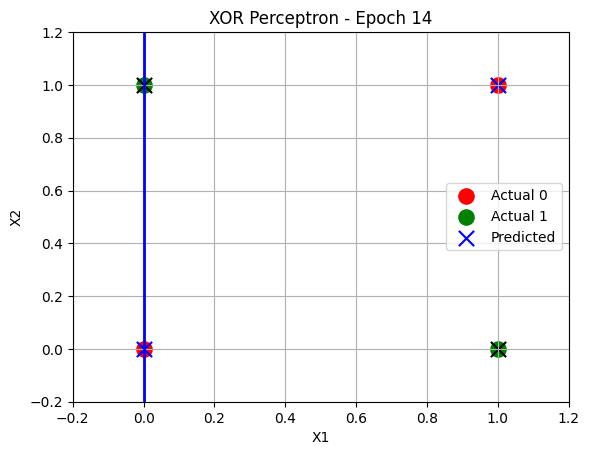


Epoch 15
X1 X2 | Target | Predicted | Error | Weights        | Bias
----------------------------------------------------------------------
0  0  |   0    |     1     |   -1   | [-0.1  0. ] | -0.10
0  1  |   1    |     0     |   1   | [-0.1  0.1] | 0.00
1  0  |   1    |     0     |   1   | [0.  0.1] | 0.10
1  1  |   0    |     1     |   -1   | [-0.1  0. ] | 0.00
Total Error: 4
Accuracy: 0.00%


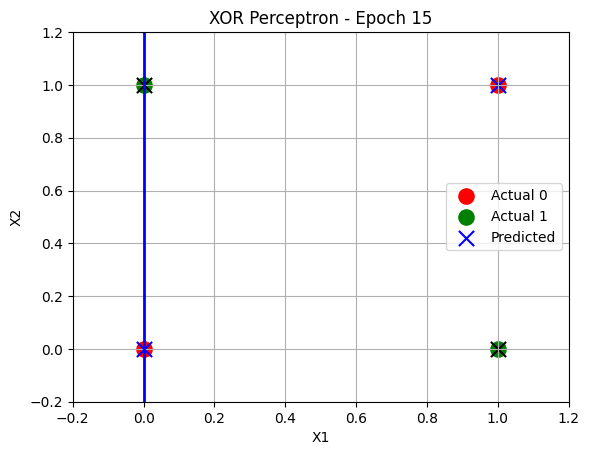


Epoch 16
X1 X2 | Target | Predicted | Error | Weights        | Bias
----------------------------------------------------------------------
0  0  |   0    |     1     |   -1   | [-0.1  0. ] | -0.10
0  1  |   1    |     0     |   1   | [-0.1  0.1] | 0.00
1  0  |   1    |     0     |   1   | [0.  0.1] | 0.10
1  1  |   0    |     1     |   -1   | [-0.1  0. ] | 0.00
Total Error: 4
Accuracy: 0.00%


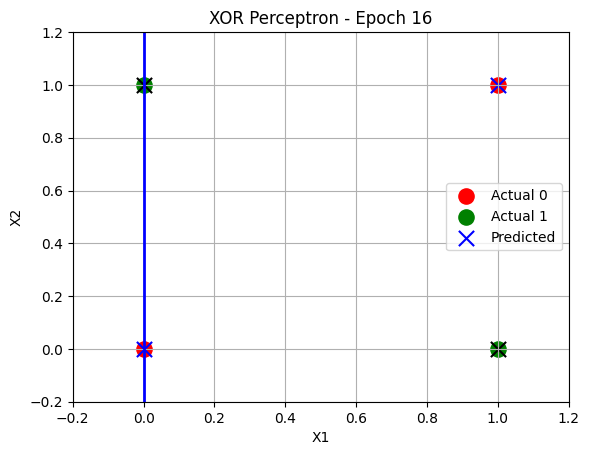


Epoch 17
X1 X2 | Target | Predicted | Error | Weights        | Bias
----------------------------------------------------------------------
0  0  |   0    |     1     |   -1   | [-0.1  0. ] | -0.10
0  1  |   1    |     0     |   1   | [-0.1  0.1] | 0.00
1  0  |   1    |     0     |   1   | [0.  0.1] | 0.10
1  1  |   0    |     1     |   -1   | [-0.1  0. ] | 0.00
Total Error: 4
Accuracy: 0.00%


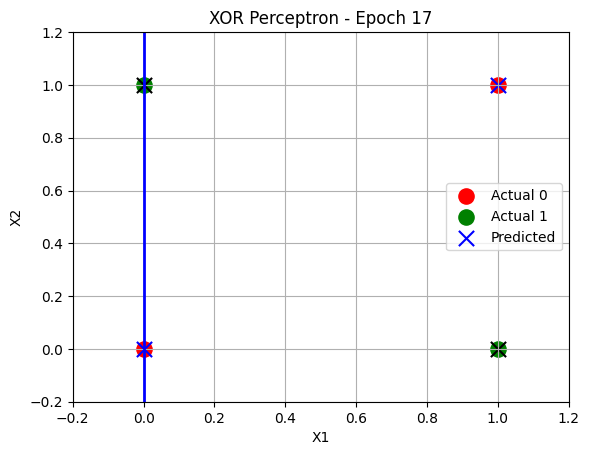


Epoch 18
X1 X2 | Target | Predicted | Error | Weights        | Bias
----------------------------------------------------------------------
0  0  |   0    |     1     |   -1   | [-0.1  0. ] | -0.10
0  1  |   1    |     0     |   1   | [-0.1  0.1] | 0.00
1  0  |   1    |     0     |   1   | [0.  0.1] | 0.10
1  1  |   0    |     1     |   -1   | [-0.1  0. ] | 0.00
Total Error: 4
Accuracy: 0.00%


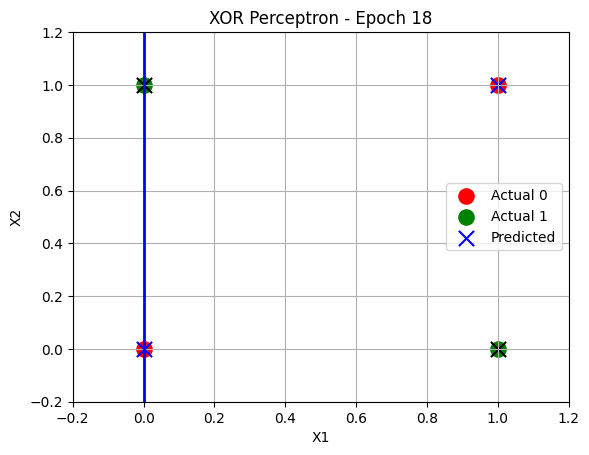


Epoch 19
X1 X2 | Target | Predicted | Error | Weights        | Bias
----------------------------------------------------------------------
0  0  |   0    |     1     |   -1   | [-0.1  0. ] | -0.10
0  1  |   1    |     0     |   1   | [-0.1  0.1] | 0.00
1  0  |   1    |     0     |   1   | [0.  0.1] | 0.10
1  1  |   0    |     1     |   -1   | [-0.1  0. ] | 0.00
Total Error: 4
Accuracy: 0.00%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# -----------------------------
# XOR Dataset
# -----------------------------
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 1, 1, 0])

# -----------------------------
# Initialization
# -----------------------------
weights = np.array([0.0, 0.0])
bias = 0.0
learning_rate = 0.1
epochs = 20

total_errors = []
accuracies = []

# -----------------------------
# Activation Function
# -----------------------------
def step_function(z):
    return 1 if z >= 0 else 0

plt.ion()

# -----------------------------
# Training
# -----------------------------
for epoch in range(epochs):
    total_error = 0
    correct = 0

    print(f"\nEpoch {epoch + 1}")
    print("X1 X2 | Target | Predicted | Error | Weights        | Bias")
    print("-" * 70)

    predictions = []

    # -------- Training pass --------
    for i in range(len(X)):
        net = np.dot(weights, X[i]) + bias
        pred = step_function(net)
        error = y[i] - pred

        weights += learning_rate * error * X[i]
        bias += learning_rate * error

        total_error += abs(error)
        predictions.append(pred)

        if pred == y[i]:
            correct += 1

        print(f"{X[i][0]}  {X[i][1]}  |   {y[i]}    |     {pred}     |   {error}   | {weights} | {bias:.2f}")

    accuracy = correct / len(X)
    accuracies.append(accuracy)
    total_errors.append(total_error)

    print(f"Total Error: {total_error}")
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # -------- Visualization --------
    plt.clf()

    # Actual points
    for i in range(len(X)):
        if y[i] == 1:
            plt.scatter(X[i][0], X[i][1], c='green', s=120, label='Actual 1' if i == 1 else "")
        else:
            plt.scatter(X[i][0], X[i][1], c='red', s=120, label='Actual 0' if i == 0 else "")

    # Predicted points
    for i in range(len(X)):
        plt.scatter(X[i][0], X[i][1],
                    marker='x',
                    s=120,
                    c='blue' if predictions[i] == 1 else 'black',
                    label='Predicted' if i == 0 else "")

    # Decision Boundary
    x_vals = np.linspace(-0.2, 1.2, 200)
    if abs(weights[1]) > 1e-6:
        y_vals = -(weights[0] * x_vals + bias) / weights[1]
        plt.plot(x_vals, y_vals, 'b-', linewidth=2, label='Decision Boundary')
    elif abs(weights[0]) > 1e-6:
        plt.axvline(x=-bias / weights[0], color='b', linewidth=2)
    else:
        plt.text(0.5, 0.5, "No valid boundary", ha='center')

    plt.xlim(-0.2, 1.2)
    plt.ylim(-0.2, 1.2)
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(f"XOR Perceptron - Epoch {epoch + 1}")
    plt.grid(True)
    plt.legend()
    plt.pause(1)

plt.ioff()

# -----------------------------
# Error vs Epoch
# -----------------------------
plt.figure()
plt.plot(range(1, epochs + 1), total_errors, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Total Error")
plt.title("Total Error vs Epochs (XOR)")
plt.grid(True)
plt.show()

# -----------------------------
# Accuracy vs Epoch
# -----------------------------
plt.figure()
plt.plot(range(1, epochs + 1), accuracies, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs (XOR)")
plt.grid(True)
plt.show()
